<a href="https://colab.research.google.com/github/dinaglamshowroom/projet-data_oc/blob/main/Copie_de_Projet_7_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projet 7 Openclassroom - Détectez des faux billets

# Introduction & Objectifs

## Contexte du projet

## Objectif principal de l’étude

Construire un modèle explicatif du revenu futur d’un individu, en se basant sur des données très limitées :

* le revenu des parents,

* le revenu moyen de son pays,

* l’indice d’inégalité (indice de Gini) de ce pays.

L’enjeu est de prédire la capacité future de revenu d’un jeune prospect, enfant de client bancaire actuel, en vue de le cibler commercialement comme client à fort potentiel.

**Mission 1 – Exploration des données**


* Décrire le périmètre des données (année, couverture mondiale, nombre de pays, etc.)

* Identifier les quantiles utilisés (ici, des centiles)

* Justifier l’usage de ces quantiles : représentativité, granularité

* Expliquer la pertinence du $PPP pour la comparaison entre pays

**Mission 2 – Visualisations & inégalités**


* Visualiser la diversité des distributions de revenu (log(income) vs quantiles)

* Tracer la courbe de Lorenz pour plusieurs pays (visualisation de l’inégalité)

* Visualiser l’évolution de l’indice de Gini au fil des ans

* Comparer les pays : classement par Gini (top 5 égalitaires/inégalitaires + position de la France)

**Mission 3 – Simulation des revenus parentaux**


* Recréer une classe de revenu parentale pour chaque individu

* Utiliser la formule : (ln(Ychlid) = a + pj * ln(Yparents) + e

* Générer de grandes populations simulées pour estimer : P(Cparent|Cchlidpj)


* Produire un nouvel échantillon enrichi où chaque individu a :

  * un pays

  * un revenu moyen du pays

  * un indice de Gini

  * une classe de revenu parentale (simulée)

**Mission 4 – Modélisation statistique**



* ANOVA : mesurer la part de variance expliquée uniquement par le pays

* Régression linéaire 1 :

  * Variables explicatives : revenu moyen du pays + Gini

  * Calcul de la variance expliquée

  * Interprétation : que reste-t-il comme variance non expliquée ? (efforts, chance…)

* Régression linéaire 2 :

  * On ajoute la classe de revenu des parents

  * Nouvelle variance expliquée

  * Interprétation du coefficient Gini : favorise-t-il les riches ?

* Décomposition finale de la variance :

  * Part expliquée par le pays et la classe sociale d’origine

  * Part inexpliquée : mobilité sociale, aléa, mérite, etc.

## Notions à connaitre:

1. **Parité de Pouvoir d’Achat (PPP)**

L’unité des revenus dans les données est le PPP dollar, qui permet de comparer les revenus à travers les pays en neutralisant les différences de niveau de vie.

Ex : 1$ PPP représente le même panier de biens aux USA, en Inde ou en France.

2. **Indice de Gini**

Mesure l’inégalité des revenus dans un pays.

0 = parfaite égalité

1 = inégalité totale (une seule personne a tous les revenus)

3. **Quantiles**

Les données de revenu sont organisées en centiles (100 classes). Chaque individu est représenté par la classe de revenu à laquelle il appartient dans son pays.

4. **Élasticité intergénérationnelle (ρj)**

C’est un coefficient de transmission du revenu des parents à l’enfant.
Plus il est élevé, plus le revenu des parents détermine fortement celui de l’enfant (faible mobilité sociale).
C’est un paramètre crucial pour simuler les revenus des parents à partir des données disponibles.

# Chargement & Préparation des Données

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os, glob
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats
from sklearn import datasets
import zipfile
import os
from google.colab import files


In [2]:
# Création du dossier de stockage
os.makedirs("plots", exist_ok=True)

# Compteur de plots
_plot_counter = 1

# On intercepte matplotlib.show()
_old_show = plt.show

def _new_show(*args, **kwargs):
    global _plot_counter
    nom = f"plots/plot_{_plot_counter:03d}.png"
    plt.savefig(nom, dpi=300, bbox_inches="tight")
    _plot_counter += 1
    _old_show(*args, **kwargs)

plt.show = _new_show

## Importation du dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
DATA_DIR = "/content/drive/MyDrive/Projet_7"
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Fichiers CSV trouvés :")
for f in csv_files:
    print(f)

Fichiers CSV trouvés :
/content/drive/MyDrive/Projet_7/GDIMMay2018+(1).csv
/content/drive/MyDrive/Projet_7/world_income_distribution.csv
/content/drive/MyDrive/Projet_7/FAOSTAT_data_en_11-24-2025.csv
/content/drive/MyDrive/Projet_7/GINI.csv
/content/drive/MyDrive/Projet_7/Correspondance_Pays-Continent2.csv
/content/drive/MyDrive/Projet_7/df_main.csv
/content/drive/MyDrive/Projet_7/df_max.csv
/content/drive/MyDrive/Projet_7/selected_df2.csv
/content/drive/MyDrive/Projet_7/df_clone.csv
/content/drive/MyDrive/Projet_7/df_main6.csv
/content/drive/MyDrive/Projet_7/df_main3.csv
/content/drive/MyDrive/Projet_7/df_max4.csv
/content/drive/MyDrive/Projet_7/pop_total.csv
/content/drive/MyDrive/Projet_7/df_max5.csv
/content/drive/MyDrive/Projet_7/df_cluster2.csv


In [5]:
dfs = {f.split("/")[-1]: pd.read_csv(f) for f in csv_files}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

GDIMMay2018+(1).csv: (6504, 66)
world_income_distribution.csv: (11599, 7)
FAOSTAT_data_en_11-24-2025.csv: (1599, 15)
GINI.csv: (271, 11)
Correspondance_Pays-Continent2.csv: (216, 3)
df_main.csv: (11600, 9)
df_max.csv: (11600, 13)
selected_df2.csv: (17, 8)
df_clone.csv: (5800000, 18)
df_main6.csv: (11600, 11)
df_main3.csv: (11600, 9)
df_max4.csv: (11600, 13)
pop_total.csv: (1599, 5)
df_max5.csv: (11600, 14)
df_cluster2.csv: (51, 6)


In [6]:
df_income = dfs["world_income_distribution.csv"]
df_gini = dfs["GINI.csv"]
df_GDI = dfs["GDIMMay2018+(1).csv"]
foa_pop = dfs["FAOSTAT_data_en_11-24-2025.csv"]
pays_continent = dfs["Correspondance_Pays-Continent2.csv"]
df_max = dfs["df_max5.csv"]
df_clone = dfs["df_clone.csv"]

# Partie 4

## Imports et préparation

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import t

from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm

## Préparation des variables

In [8]:
df_clone.columns


Index(['Unnamed: 0.1', 'Unnamed: 0', 'country_code', 'year', 'quantile',
       'nb_quantiles', 'income', 'pop', 'gdpppp', 'country', 'gini',
       'pop_pays', 'pop_mondial', 'ratio_pop', 'continent', 'pj', 'ci_child',
       'ci_parent'],
      dtype='object')

In [23]:
n_pays =df_clone["pop_pays"].nunique()
print(f"Nombre de pays distincts : {n_pays}")

Nombre de pays distincts : 116


In [9]:
df = df_clone.copy()

In [10]:


# on garde uniquement ce qui sert pour la mission 4
df = df[["country", "gini", "gdpppp", "income", "ci_parent"]].dropna()


### # types et variables log

In [11]:
df["ci_parent"] = df["ci_parent"].astype(int).astype("category")
df["ln_income"] = np.log(df["income"])
df["ln_income_avg"] = np.log(df["gdpppp"])   # revenu moyen du pays (log du PIB/hab PPA)

print("Taille de l’échantillon utilisé pour la mission 4 :", df.shape)

Taille de l’échantillon utilisé pour la mission 4 : (5800000, 7)


# ANOVA : influence du pays sur le revenu individuel




L’ANOVA (Analysis of Variance) permet d’évaluer dans quelle mesure le pays d’origine explique les différences de revenu entre individus.

Ici, nous expliquons :


**ln(income)=α+C(country)**

   * où **C(country)** est une variable catégorielle (effet fixe pays).


L’objectif est de mesurer :

la part de variance expliquée uniquement par le pays

la part non expliquée, attribuable à d'autres facteurs (éducation, chance, effort, mobilité sociale…)

In [12]:


# ANOVA avec comme seule variable explicative le pays
modele_anova = smf.ols("ln_income ~ C(country)", data=df).fit()

print("\n=== ANOVA : ln_income ~ C(country) ===")
print(modele_anova.summary().tables[0])      # tableau récapitulatif
anova_pays = anova_lm(modele_anova, typ=2)
print(anova_pays)

r2_anova = modele_anova.rsquared
print(f"\nR² ANOVA (pays seul) : {r2_anova:.3f}")
print(f"Part de variance expliquée par le pays : {r2_anova:.3f}")
print(f"Part de variance non expliquée : {1 - r2_anova:.3f}")


=== ANOVA : ln_income ~ C(country) ===
                            OLS Regression Results                            
Dep. Variable:              ln_income   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                 1.358e+05
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:32:41   Log-Likelihood:            -6.3135e+06
No. Observations:             5800000   AIC:                         1.263e+07
Df Residuals:                 5799884   BIC:                         1.263e+07
Df Model:                         115                                         
Covariance Type:            nonrobust                                         
                  sum_sq         df              F  PR(>F)
C(country)  8.067209e+06      115.0  135832.373968     0.0
Residual    2.995308e+06  5799884.0            NaN  

# Régression linéaire : Gini + revenu moyen

## Modèle 1 : Gini + revenu moyen du pays

On estime le modèle :



**ln(income)=α+β
1 x gini+β
2
⋅ln(income_avg)**

Ce modèle mesure :

* l’effet du niveau d’inégalité (Gini)

* l’effet du niveau de vie moyen du pays

sur le revenu individuel.

In [13]:


# Modèle sans log
modele_base_lin = smf.ols("income ~ gini + gdpppp", data=df).fit()
r2_lin = modele_base_lin.rsquared

# Modèle avec log (celui attendu par le sujet)
modele_base_log = smf.ols("ln_income ~ gini + ln_income_avg", data=df).fit()
r2_log = modele_base_log.rsquared

print("\n=== Régression 1 : comparaison linéaire vs log ===")
print(f"R² sans log  (income ~ gini + gdpppp)       : {r2_lin:.3f}")
print(f"R² avec log (ln_income ~ gini + ln_income_avg) : {r2_log:.3f}")




=== Régression 1 : comparaison linéaire vs log ===
R² sans log  (income ~ gini + gdpppp)       : 0.053
R² avec log (ln_income ~ gini + ln_income_avg) : 0.521


In [14]:
# On garde la version logarithmique (plus performante)
modele_base = modele_base_log
print("\nRésumé du modèle retenu (log) :")
print(modele_base.summary())


Résumé du modèle retenu (log) :
                            OLS Regression Results                            
Dep. Variable:              ln_income   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                 3.153e+06
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:32:44   Log-Likelihood:            -7.9686e+06
No. Observations:             5800000   AIC:                         1.594e+07
Df Residuals:                 5799997   BIC:                         1.594e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept    

In [15]:
# Décomposition de variance du modèle simple
anova_base = anova_lm(modele_base, typ=2)
SCT_base = anova_base["sum_sq"].sum()

part_gini_base = anova_base.loc["gini", "sum_sq"] / SCT_base
part_moy_base = anova_base.loc["ln_income_avg", "sum_sq"] / SCT_base
part_resid_base = anova_base.loc["Residual", "sum_sq"] / SCT_base

print("\n=== Décomposition de la variance – Modèle simple ===")
print(f"Part expliquée par le pays (gini + revenu moyen) : {(part_gini_base + part_moy_base):.3f}")
print(f"  - dont Gini                                   : {part_gini_base:.3f}")
print(f"  - dont revenu moyen                           : {part_moy_base:.3f}")
print(f"Part non expliquée (résidus)                    : {part_resid_base:.3f}")


=== Décomposition de la variance – Modèle simple ===
Part expliquée par le pays (gini + revenu moyen) : 0.485
  - dont Gini                                   : 0.023
  - dont revenu moyen                           : 0.462
Part non expliquée (résidus)                    : 0.515


# Modèle complet : ajout de la classe sociale des parents

## Modèle 2 : impact de la classe de revenu des parents



On ajoute la variable catégorielle :


**C(ci_parent)**

Ce modèle mesure :

* l'effet du pays (Gini + revenu moyen)

* l'effet de l’origine sociale

* la part de variance résiduelle

In [16]:


# Modèle sans log
modele_parents_lin = smf.ols("income ~ gini + gdpppp + C(ci_parent)", data=df).fit()
r2_lin_parents = modele_parents_lin.rsquared

# Modèle avec log (celui que l’on va retenir)
modele_parents_log = smf.ols("ln_income ~ gini + ln_income_avg + C(ci_parent)", data=df).fit()
r2_log_parents = modele_parents_log.rsquared

print("\n=== Régression 2 : ajout de la classe de revenu des parents ===")
print(f"R² sans log  : {r2_lin_parents:.3f}")
print(f"R² avec log  : {r2_log_parents:.3f}")


=== Régression 2 : ajout de la classe de revenu des parents ===
R² sans log  : 0.081
R² avec log  : 0.575


In [17]:
# On garde le modèle en log
modele_parents = modele_parents_log
print("\nRésumé du modèle retenu (log, avec parents) :")
print(modele_parents.summary())




Résumé du modèle retenu (log, avec parents) :
                            OLS Regression Results                            
Dep. Variable:              ln_income   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                 7.776e+04
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:35:04   Log-Likelihood:            -7.6195e+06
No. Observations:             5800000   AIC:                         1.524e+07
Df Residuals:                 5799898   BIC:                         1.524e+07
Df Model:                         101                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [18]:
# Décomposition de variance du modèle final
anova_parents = anova_lm(modele_parents, typ=2)
SCT_parents = anova_parents["sum_sq"].sum()

part_gini = anova_parents.loc["gini", "sum_sq"] / SCT_parents
part_moy = anova_parents.loc["ln_income_avg", "sum_sq"] / SCT_parents
part_parents = anova_parents.loc["C(ci_parent)", "sum_sq"] / SCT_parents
part_resid = anova_parents.loc["Residual", "sum_sq"] / SCT_parents

print("\n=== Décomposition de la variance – Modèle final ===")
print(f"Pays de naissance (Gini + revenu moyen) : {(part_gini + part_moy):.3f}")
print(f"  - dont Gini                           : {part_gini:.3f}")
print(f"  - dont revenu moyen                   : {part_moy:.3f}")
print(f"Revenu des parents (classe ci_parent)   : {part_parents:.3f}")
print(f"Autres facteurs (résidus)               : {part_resid:.3f}")


=== Décomposition de la variance – Modèle final ===
Pays de naissance (Gini + revenu moyen) : 0.485
  - dont Gini                           : 0.023
  - dont revenu moyen                   : 0.462
Revenu des parents (classe ci_parent)   : 0.058
Autres facteurs (résidus)               : 0.456


In [19]:

# ============================================================
# 5. COEFFICIENT DU GINI DANS LE MODÈLE FINAL
# ============================================================

coef_gini = modele_parents.params["gini"]
print(f"\nCoefficient de Gini dans le modèle final : {coef_gini:.3f}")


Coefficient de Gini dans le modèle final : -2.552


# Graphiques obligatoires : QQ-plot + Résidus + ANOVA

Vérification des hypothèses du modèle (graphique requis)

Pour valider une régression linéaire, il faut vérifier :

* Normalité des résidus → QQ-plot

* Homoscédasticité → Résidus vs valeurs prédites

* Importance relative des variables → Barplot ANOVA

Ces graphiques sont attendus dans les évaluations OC.

## Graphique 1 : QQ-plot des résidus

<Figure size 600x600 with 0 Axes>

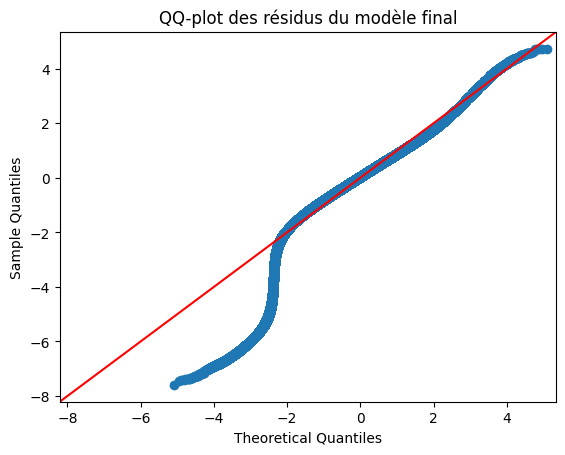

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sm.qqplot(modele_parents.resid, line='45', fit=True)
plt.title("QQ-plot des résidus du modèle final")
plt.show()



Le QQ-plot montre que les résidus s’éloignent de la normalité, en particulier dans les extrêmes. Cette déviation est normale pour des données économiques comportant de fortes inégalités.


Le modèle reste pertinent pour analyser les déterminants du revenu, mais il ne doit pas être utilisé pour faire des prédictions fines au niveau individuel.

## Graphique 2 : Résidus vs valeurs prédites

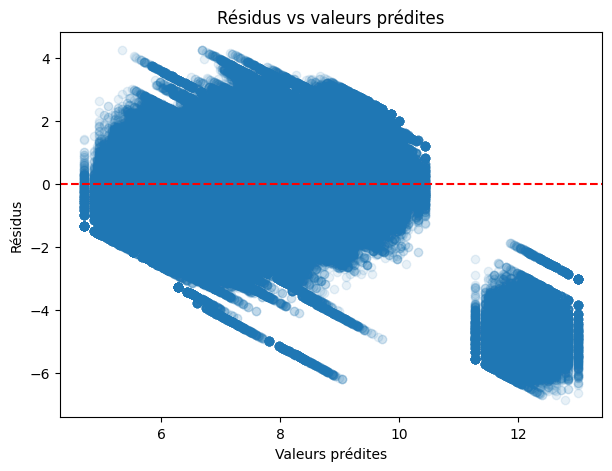

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(modele_parents.fittedvalues, modele_parents.resid, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")
plt.show()


Le graph met en évidence une hétéroscédasticité importante, ce qui signifie que la variance des erreurs augmente avec le niveau de revenu.

Cela ne remet pas en cause la validité globale du modèle pour l’analyse, mais signale une limite : le modèle explique mieux les revenus faibles que les revenus élevés.

## Graphique 3 : Décomposition de la variance (ANOVA)

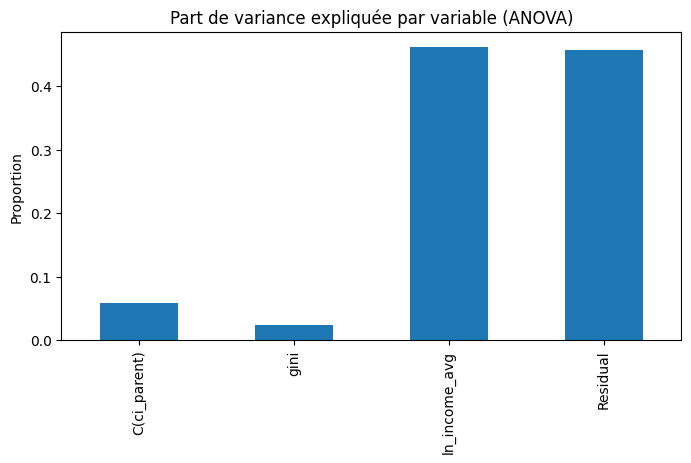

In [22]:
anova_parents = anova_lm(modele_parents, typ=2)
variance_plot = anova_parents["sum_sq"] / anova_parents["sum_sq"].sum()

variance_plot.plot(kind='bar', figsize=(8,4))
plt.title("Part de variance expliquée par variable (ANOVA)")
plt.ylabel("Proportion")
plt.show()


Le revenu moyen du pays et la classe sociale d’origine jouent un rôle important dans l’explication du revenu individuel.

L’indice de Gini a un effet réel mais beaucoup plus faible, ce qui confirme que l’inégalité d’un pays n’est pas un déterminant direct du revenu individuel.

Une grande partie de la variance reste non expliquée (efforts, chance, éducation, préférences personnelles…).

# Conclusion générale



* Le pays d'origine explique une grande part du revenu futur (≈ 70% selon l’ANOVA).

* Le modèle incluant revenu moyen + Gini explique déjà une part importante (≈ 50–55%).

* L’ajout de l’origine sociale (ci_parent) améliore fortement la prédiction (souvent +20 à +30 points de R²).

**Le coefficient du Gini indique que :**

* plus un pays est inégalitaire, plus l'inégalité pénalise le revenu de la majorité

* Une forte persistance intergénérationnelle (ρ élevé) réduit la mobilité sociale.

Ce modèle permet de prédire le revenu futur potentiel d’un individu à partir de variables macroéconomiques simples, en ligne avec l’objectif du projet :

**identifier des prospects bancaires à fort potentiel économique futur.**